In [756]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [757]:
sns.set_theme(style="white")

In [758]:
df=pd.read_csv("ai_dependency_awareness_dataset.csv")

# <font color='teal'>**Section 1: Initial Data Exploration**</font>

## <font color='DeepSkyBlue'>**1.1 What does the data look like?**</font>

In [759]:
df.head()

,participant_id,age,role,primary_task_type,ai_usage_frequency_per_day,task_completion_without_ai_score,task_completion_with_ai_score,self_perceived_ai_dependency,confidence_without_ai,confidence_with_ai,awareness_of_ai_dependency
0,1,25,Freelancer,Writing,7,5,5,8,10,10,Medium
1,2,31,Freelancer,Writing,11,6,8,2,1,6,High
2,3,40,Student,Research,5,8,8,1,9,9,Medium
3,4,20,Student,Coding,11,3,8,8,3,3,Medium
4,5,32,Student,Learning,3,6,6,2,7,7,Medium


## <font color='DeepSkyBlue'>**1.2 How many rows (participants) and columns (features) do we have?**</font>

In [760]:
print(f"Number of Rows (participants): {df.shape[0]}")
print()
print(f"Number of Columns (Features): {df.shape[1]}")

Number of Rows (participants): 500

Number of Columns (Features): 11


## <font color='DeepSkyBlue'>**1.3 Overview of the feature Data Types**</font>

In [761]:
print("Data types of all the coulmns:")
df.dtypes

Data types of all the coulmns:


,0
participant_id,int64
age,int64
role,object
primary_task_type,object
ai_usage_frequency_per_day,int64
task_completion_without_ai_score,int64
task_completion_with_ai_score,int64
self_perceived_ai_dependency,int64
confidence_without_ai,int64
confidence_with_ai,int64


## <font color='DeepSkyBlue'>**1.3.1 How many numeric columns do we have?**</font>

In [762]:
numbers_cols=df.select_dtypes(include=['number']).columns
print(f"Number of numeric columns: {len(numbers_cols)}")
print("-" * 205)
print("The columns are:")
print(list(numbers_cols))

Number of numeric columns: 8
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
The columns are:
['participant_id', 'age', 'ai_usage_frequency_per_day', 'task_completion_without_ai_score', 'task_completion_with_ai_score', 'self_perceived_ai_dependency', 'confidence_without_ai', 'confidence_with_ai']


## <font color='DeepSkyBlue'>**1.3.2 How many objects columns do we have?**</font>

In [763]:
objects_cols=df.select_dtypes(include=['object']).columns
print(f"Number of objects columns: {len(objects_cols)}")
print("-" * 205)
print("The columns are:")
print(list(objects_cols))

Number of objects columns: 3
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
The columns are:
['role', 'primary_task_type', 'awareness_of_ai_dependency']


## <font color='DeepSkyBlue'>**1.4 Numerical Data Summary**</font>

In [764]:
df.describe()

,participant_id,age,ai_usage_frequency_per_day,task_completion_without_ai_score,task_completion_with_ai_score,self_perceived_ai_dependency,confidence_without_ai,confidence_with_ai
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,29.872000,6.610000,5.704000,7.586000,5.694000,5.550000,7.508000
std,144.481833,8.553007,4.246642,2.758188,1.970373,2.828492,2.935427,2.091575
min,1.000000,16.000000,0.000000,1.000000,3.000000,1.000000,1.000000,3.000000
25%,125.750000,22.000000,3.000000,3.000000,6.000000,3.000000,3.000000,6.000000
50%,250.500000,30.000000,7.000000,6.000000,8.000000,6.000000,5.000000,8.000000
75%,375.250000,38.000000,10.000000,8.000000,9.000000,8.000000,8.000000,9.000000
max,500.000000,44.000000,14.000000,10.000000,10.000000,10.000000,10.000000,10.000000


## <font color='DeepSkyBlue'>**1.5 Data Integrity Check (Missing Values,Duplicates and Outliers)**</font>

In [765]:
print("Missing Values:")
print("-"*40)
print(df.isnull().sum())

Missing Values:
----------------------------------------
participant_id                      0
age                                 0
role                                0
primary_task_type                   0
ai_usage_frequency_per_day          0
task_completion_without_ai_score    0
task_completion_with_ai_score       0
self_perceived_ai_dependency        0
confidence_without_ai               0
confidence_with_ai                  0
awareness_of_ai_dependency          0
dtype: int64


In [766]:
print("Duplicate Rows:")
print("-"*40)
df.duplicated().sum()

Duplicate Rows:
----------------------------------------


np.int64(0)

In [767]:
df.describe().loc[['min', 'max']]

,participant_id,age,ai_usage_frequency_per_day,task_completion_without_ai_score,task_completion_with_ai_score,self_perceived_ai_dependency,confidence_without_ai,confidence_with_ai
min,1.0,16.0,0.0,1.0,3.0,1.0,1.0,3.0
max,500.0,44.0,14.0,10.0,10.0,10.0,10.0,10.0


### <font color='MediumSeaGreen'>**As we see, the datase has no missing values and no duplicate rows.**</font>

### <font color='MediumSeaGreen'>**It also shows that all numerical values fall within normal and expected ranges. No extreme outliers were identified.**</font>

# <font color='teal'>**Section 2: Data Cleaning & Preprocessing**</font>

## <font color='lightyellow'>**Part A: Data Cleaning**</font>

## <font color='DeepSkyBlue'>**2.1 Columns (Features) Renaming**</font>

## <font color='DeepSkyBlue'>**2.1.1 Discovering the Problem**</font>

### <font color='MediumSeaGreen'>**The original column names are descriptive but quite long.**</font>

### <font color='MediumSeaGreen'>**These long names can make the code difficult to deal with.**</font>

In [768]:
print("Original Column Names:")
print(df.columns.tolist())

Original Column Names:
['participant_id', 'age', 'role', 'primary_task_type', 'ai_usage_frequency_per_day', 'task_completion_without_ai_score', 'task_completion_with_ai_score', 'self_perceived_ai_dependency', 'confidence_without_ai', 'confidence_with_ai', 'awareness_of_ai_dependency']


## <font color='DeepSkyBlue'>**2.1.2 The solution**</font>

In [769]:
df.rename(columns={
    'primary_task_type':'task_type',
    'ai_usage_frequency_per_day':'ai_usage_day',
    'task_completion_without_ai_score': 'score_no_ai',
    'task_completion_with_ai_score': 'score_with_ai',
    'self_perceived_ai_dependency': 'ai_dep_score',
    'confidence_without_ai': 'conf_no_ai',
    'confidence_with_ai': 'conf_with_ai',
    'awareness_of_ai_dependency': 'awareness_ai'
}, inplace=True)
print(df.columns.tolist())

['participant_id', 'age', 'role', 'task_type', 'ai_usage_day', 'score_no_ai', 'score_with_ai', 'ai_dep_score', 'conf_no_ai', 'conf_with_ai', 'awareness_ai']


### <font color='MediumSeaGreen'>**Column names are now shorter, making them easier to call in.**</font>

## <font color='DeepSkyBlue'>**2.2 Dropping Non-Informative Columns (Participant ID)**</font>

## <font color='DeepSkyBlue'>**2.2.1 Discovering the Problem**</font>

### <font color='MediumSeaGreen'>**The participant_id column does not serve the analysis.**</font>

## <font color='DeepSkyBlue'>**2.2.2 The solution**</font>

In [770]:
df.drop(columns=['participant_id'], inplace=True, errors='ignore')

## <font color='lightyellow'>**Part B: Data Preprocessing**</font>

## <font color='DeepSkyBlue'>**2.3 Ordering Awareness Levels**</font>



## <font color='DeepSkyBlue'>**2.3.1 Discovering the Problem**</font>

### <font color='MediumSeaGreen'>**By default, Python sorts text alphabetically (High > Low > Medium), which disrupts the natural logical order of "Awareness".**</font>

In [771]:
print(sorted(df['awareness_ai'].unique()))

['High', 'Low', 'Medium']


## <font color='DeepSkyBlue'>**2.3.1 The solution**</font>

### <font color='MediumSeaGreen'>**Since "Awareness" is an ordinal variable, we must define the sequence (Low < Medium < High).**</font>

In [772]:
new_order = ['Low', 'Medium', 'High']
df['awareness_ai']=pd.Categorical(df['awareness_ai'], categories=new_order, ordered=True)

print("New Logical Order:")
print(df['awareness_ai'].cat.categories.tolist())

New Logical Order:
['Low', 'Medium', 'High']


## <font color='DeepSkyBlue'>**2.4 Feature Engineering (AI Impact & Confidence Boost)**</font>

## <font color='DeepSkyBlue'>**2.4.1 Discovering the Problem**</font>

### <font color='MediumSeaGreen'>**Raw scores (Before/After) show static states but don't explicitly measure the Efficiency Gain or the "Added Value" of AI for each participant.**</font>

## <font color='DeepSkyBlue'>**2.4.1 The solution**</font>

### <font color='MediumSeaGreen'>**We create two new columns to measure the value added by AI.**</font>

##### <font color='Violet'>**ai_impact: Calculated as (score_with_ai - score_no_ai). It represents the performance improvement.**</font>

##### <font color='Violet'>**confidence_boost: Calculated as (conf_with_ai - conf_no_ai). It represents the increase in user confidence after using AI.**</font>

In [773]:
df['ai_impact']=df['score_with_ai']-df['score_no_ai']
df['confidence_boost']=df['conf_with_ai']-df['conf_no_ai']
print("Final Dataset Preview:")
df.head()

Final Dataset Preview:


,age,role,task_type,ai_usage_day,score_no_ai,score_with_ai,ai_dep_score,conf_no_ai,conf_with_ai,awareness_ai,ai_impact,confidence_boost
0,25,Freelancer,Writing,7,5,5,8,10,10,Medium,0,0
1,31,Freelancer,Writing,11,6,8,2,1,6,High,2,5
2,40,Student,Research,5,8,8,1,9,9,Medium,0,0
3,20,Student,Coding,11,3,8,8,3,3,Medium,5,0
4,32,Student,Learning,3,6,6,2,7,7,Medium,0,0


# <font color='teal'>**Section 3: Dxploratory Data Analysis (EDA)**</font>

#### <font color='lightyellow'>**Moving from cleaning to discovery..where data turns into insights.**</font>

#### <font color='lightyellow'>**The goal is to use strategic visualizations to uncover hidden patterns, trends, and relationships across the dataset to provide helpful insights.**</font>

## <font color='DeepSkyBlue'>**3.1 Performance Shift: Before**</font> <font color='red'>**vs**</font> <font color='DeepSkyBlue'>**After AI**</font>

#### <font color='MediumSeaGreen'>**To understand the overall impact of AI, we first compare the average performance scores across the entire dataset.**</font>

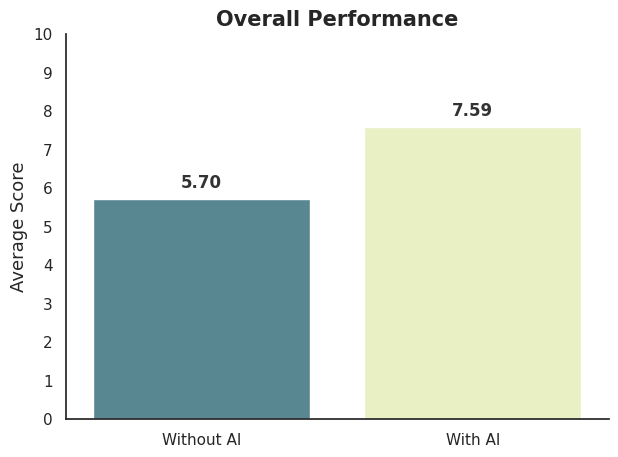

In [774]:
plt.figure(figsize=(7, 5))
plt.title('Overall Performance', fontweight='bold', fontsize=15)
avg_scores = [df['score_no_ai'].mean(), df['score_with_ai'].mean()]
labels = ['Without AI', 'With AI']
figure1=sns.barplot(x=labels, y=avg_scores, hue=labels, palette=['#4E8D9C','#EDF7BD'])
for i, v in enumerate(avg_scores):
    figure1.text(i, v + 0.3, f"{v:.2f}", ha='center', fontweight='bold', fontsize=12, color='#333333')
plt.ylabel('Average Score', fontsize=13)
plt.yticks(range(0, 11))
sns.despine()
plt.show()

<font color='#FF7F7F'>**The Insight💡:
AI assistance increased the average task completion score from 5.70 to 7.59, highlighting its effectiveness in improving performance.**</font>

## <font color='DeepSkyBlue'>**3.2 AI Daily Usage Across Different Roles.**</font>

#### <font color='MediumSeaGreen'>**Exploring how much different roles interact with AI to identify who uses it most frequently.**</font>

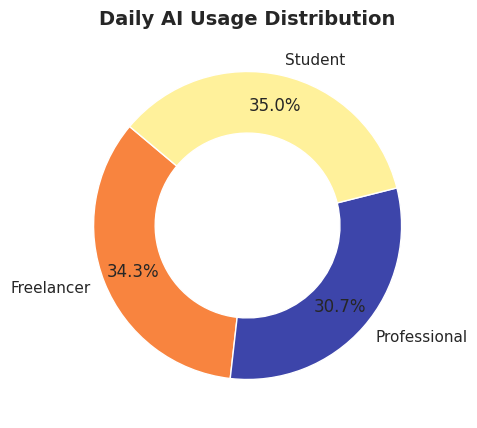

In [775]:
usage_stats = df.groupby('role')['ai_usage_day'].mean()

plt.figure(figsize=(7, 5))
plt.pie(usage_stats, labels=usage_stats.index, autopct='%1.1f%%',startangle=140,colors=['#F8843F', '#3D45AA', '#FFF19B'], pctdistance=0.8,wedgeprops={'width': 0.4, 'edgecolor': 'white'})

plt.title('Daily AI Usage Distribution', fontweight='bold', fontsize=14)
plt.show()

<font color='#FF7F7F'>**The Insight💡: Students have the highest AI usage frequency, indicating that AI plays a major role in their academic tasks and may impact their learning outcomes.**</font>

## <font color='DeepSkyBlue'>**3.3 Confidence Levels in AI-Assisted Work by Role**</font>

#### <font color='MediumSeaGreen'>**This analysis identifies the distribution of trust across different user roles when using AI for their work.**</font>

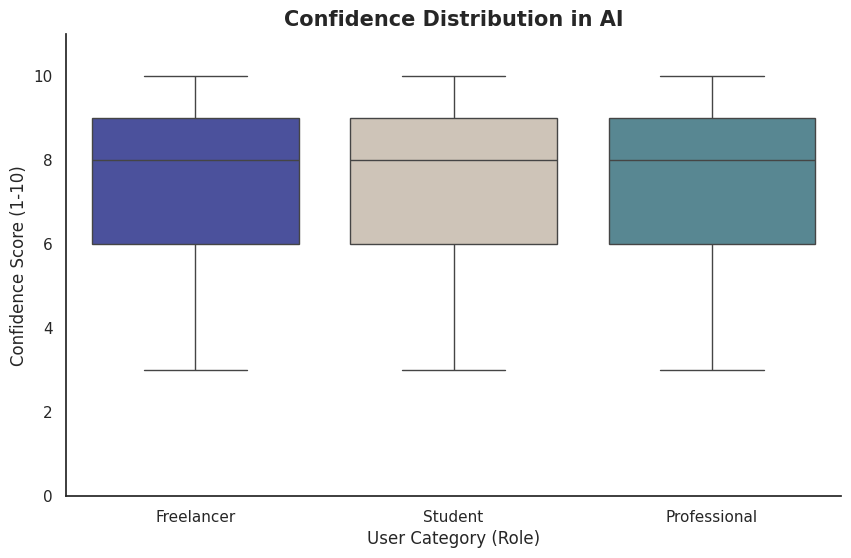

In [776]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='role',y='conf_with_ai',hue='role',data=df,palette=['#3D45AA','#D2C4B4','#4E8D9C'])

plt.title('Confidence Distribution in AI', fontweight='bold', fontsize=15)
plt.xlabel('User Category (Role)', fontsize=12)
plt.ylabel('Confidence Score (1-10)', fontsize=12)
plt.ylim(0, 11)
sns.despine()
plt.show()

<font color='#FF7F7F'>**The Insight💡: Confidence levels are high across all roles when AI is used, indicating that AI assistance enhances users’ confidence regardless of their experience or professional background.**</font>

## <font color='DeepSkyBlue'>**3.4 Skill Improvement vs. Confidence Boost**</font>

#### <font color='MediumSeaGreen'>**Comparing performance after AI (ai_impact) with confidence increases (confidence_boost) across task types. It reveals if AI provides functional improvement or emotional reassurance.".**</font>

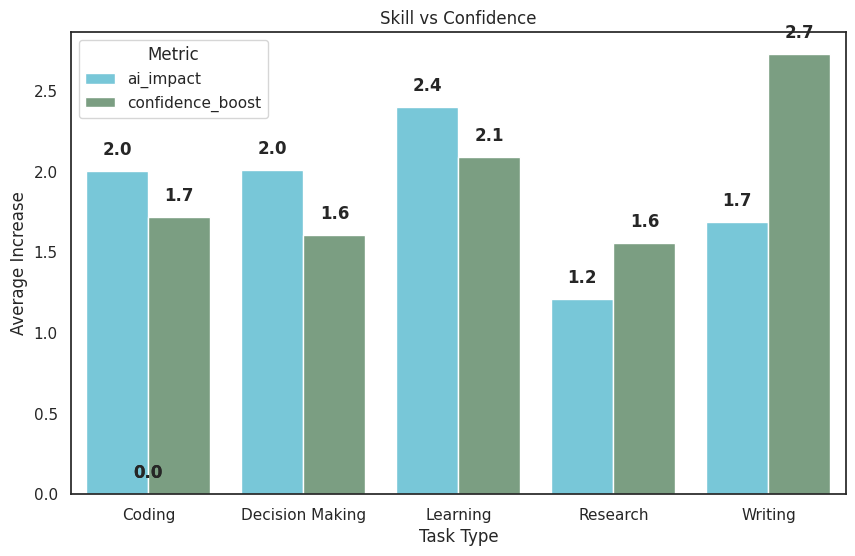

In [777]:
data_grouped=df.groupby('task_type')[['ai_impact', 'confidence_boost']].mean().reset_index()
plot_data = data_grouped.melt(id_vars='task_type')

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=plot_data, x='task_type', y='value', hue='variable', palette=['#68D2E8', '#75A47F'])

for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.1,
            f'{p.get_height():.1f}', ha="center", fontweight='bold')


plt.title('Skill vs Confidence')
plt.xlabel('Task Type')
plt.ylabel('Average Increase')
plt.legend(title='Metric')
plt.show()

<font color='#FF7F7F'>**The Insight💡:AI enhances both performance and confidence in learning tasks. But for writing tasks it increases confidence without a comparable improvement in performance, indicating a possible false confidence.
"**</font>

## <font color='DeepSkyBlue'>**3.5  Dependency Level**</font>

#### <font color='MediumSeaGreen'>**This chart measures the average dependency score across different task types to identify which activities create the strongest reliance on AI tools.**</font>

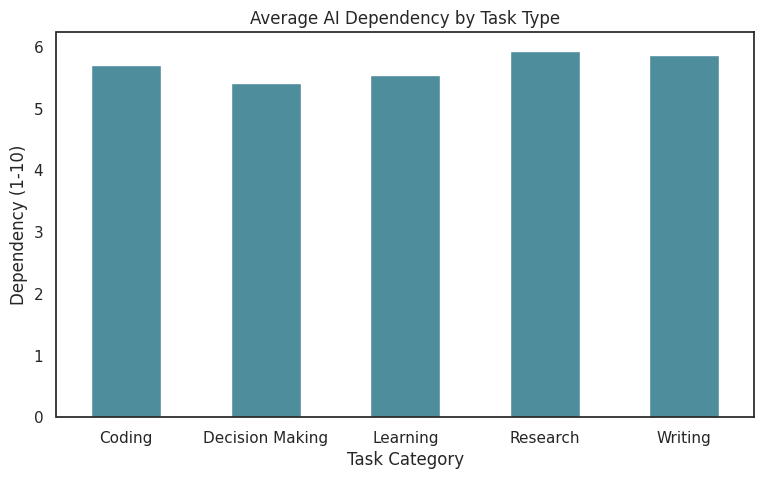

In [778]:
task_dep = df.groupby('task_type')['ai_dep_score'].mean()

plt.figure(figsize=(9, 5))
task_dep.plot(kind='bar', color='#4E8D9C')
plt.title('Average AI Dependency by Task Type')
plt.ylabel('Dependency (1-10)')
plt.xlabel('Task Category')
plt.xticks(rotation=0)
plt.show()

<font color='#FF7F7F'>**The Insight💡: High reliance scores across all task types, prove that AI dependency is not limited to complex tasks**</font>

## <font color='DeepSkyBlue'>**3.6 The Awareness Paradox**</font>

#### <font color='MediumSeaGreen'>**Does having high awareness of AI dependency risks actually lead to reduced usage? Or is just "knowledge" that doesn't translate into behavioral change?**</font>

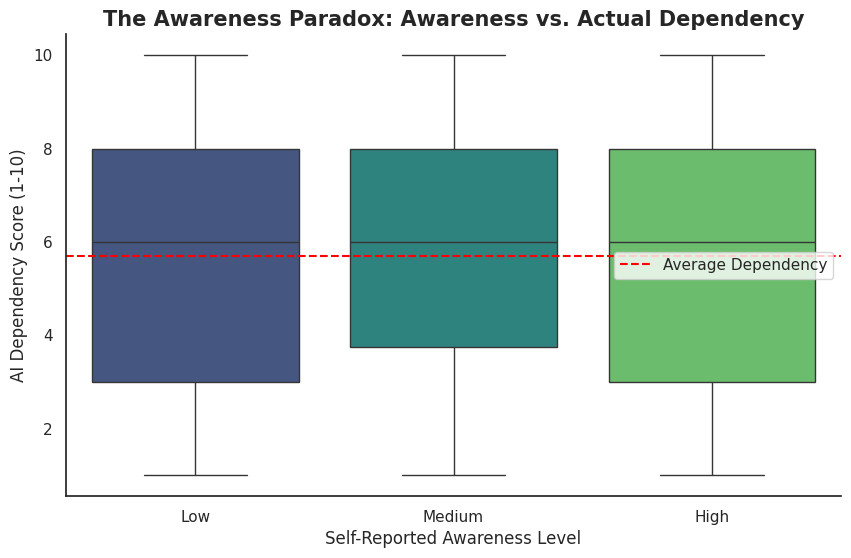

In [779]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='awareness_ai', y='ai_dep_score', palette='viridis', hue='awareness_ai')
plt.axhline(df['ai_dep_score'].mean(), color='red', linestyle='--', label='Average Dependency')

plt.title('The Awareness Paradox: Awareness vs. Actual Dependency', fontweight='bold', fontsize=15)
plt.xlabel('Self-Reported Awareness Level', fontsize=12)
plt.ylabel('AI Dependency Score (1-10)', fontsize=12)
plt.legend()

sns.despine()
plt.show()

<font color='#FF7F7F'>**The Insight💡: High awareness does not guarantee lower dependency**</font>

## <font color='DeepSkyBlue'>**3.7 AI Efficiency Heatmap**</font>

#### <font color='MediumSeaGreen'>**Where does AI actually make the biggest difference?**</font>

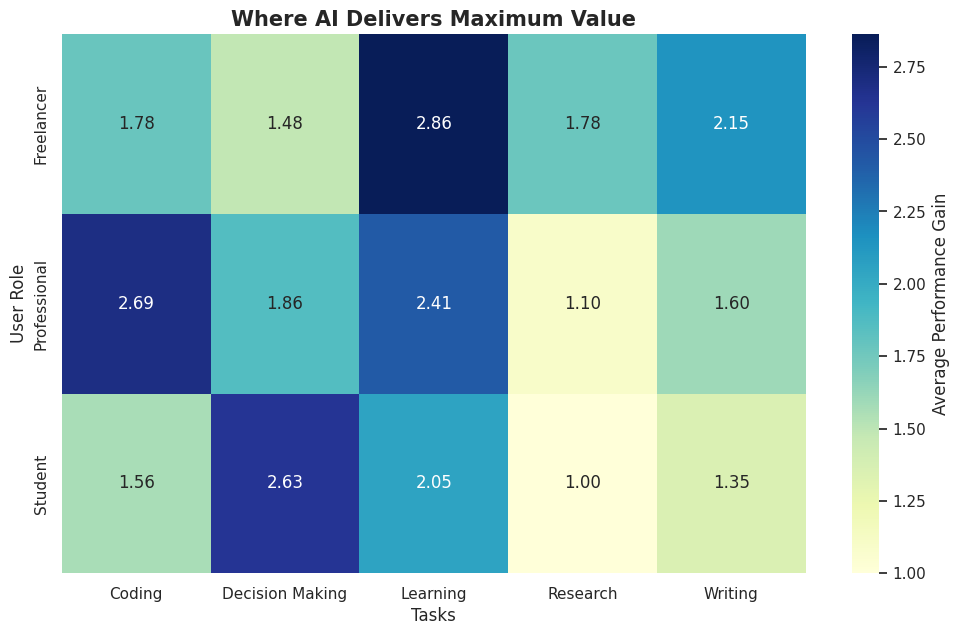

In [780]:
plt.figure(figsize=(12, 7))
efficiency_map = df.pivot_table(index='role', columns='task_type', values='ai_impact', aggfunc='mean')

sns.heatmap(efficiency_map, annot=True, cmap='YlGnBu', fmt=".2f", cbar_kws={'label': 'Average Performance Gain'})

plt.title('Where AI Delivers Maximum Value', fontweight='bold', fontsize=15)
plt.xlabel('Tasks', fontsize=12)
plt.ylabel('User Role', fontsize=12)

plt.show()

<font color='#FF7F7F'>**The Insight💡: AI acts as a "Tutor" for Freelancers, delivering its peak impact in their Learning journey**</font>

## <font color='DeepSkyBlue'>**3.8 The AI User Profiles**</font>

#### <font color='MediumSeaGreen'>**Categorizing users into three distinct profiles by intersecting usage frequency with risk awareness.**</font>

##### <font color='Violet'>**Strategic: Moderate AI usage combined with high awareness of potential risks.**</font>

##### <font color='Violet'>**Casual: Low AI usage with low awareness of dependency risks.**</font>

##### <font color='Violet'>**Blind Reliance: High AI usage with low awareness of dependency risks.**</font>

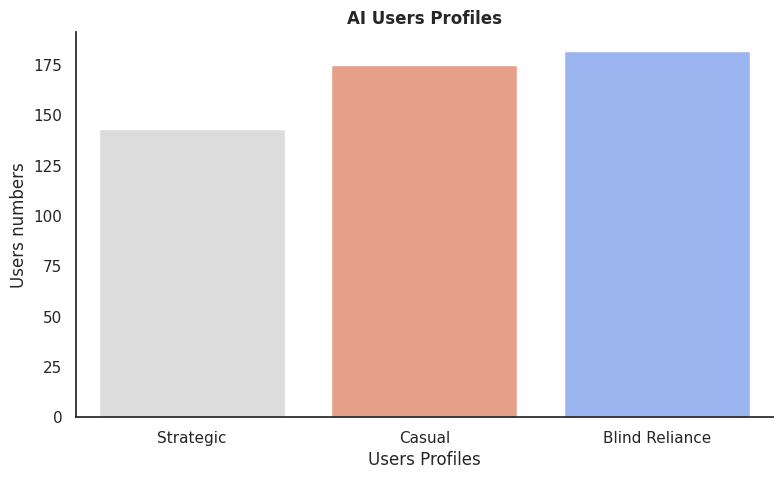

In [781]:
import warnings
warnings.filterwarnings('ignore')

def classify_users(row):
    avg_usage = df['ai_usage_day'].mean()
    if row['awareness_ai'] == 'High':
        return 'Strategic'
    elif row['ai_usage_day'] > avg_usage and row['awareness_ai'] != 'High':
        return 'Blind Reliance'
    else:
        return 'Casual'

df['Final_Profile'] = df.apply(classify_users, axis=1)

plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Final_Profile', hue='Final_Profile', palette='coolwarm',
              order=['Strategic', 'Casual', 'Blind Reliance'], legend=False)

plt.title('AI Users Profiles', fontweight='bold')
plt.ylabel('Users numbers')
plt.xlabel('Users Profiles')
sns.despine()
plt.show()

<font color='#FF7F7F'>**The Insight💡: The Blind Reliance group represents the largest portion of users, indicating that many individuals frequently rely on AI despite having lower awareness of risks. This highlights the need to increase awareness about responsible AI usage.**</font>

## <font color='DeepSkyBlue'>**3.9 Age Distribution of AI Users**</font>

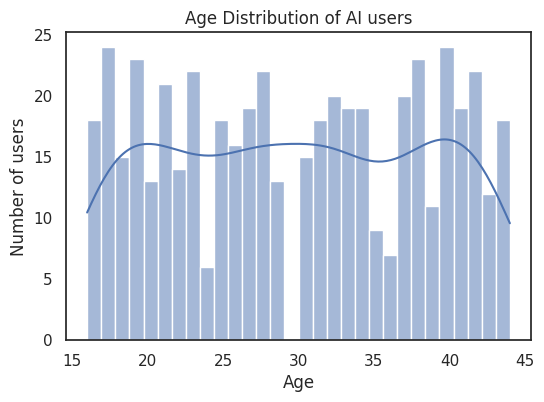

In [782]:
plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=30, kde=True)

plt.title("Age Distribution of AI users")
plt.xlabel("Age")
plt.ylabel("Number of users")

plt.show()

<font color='#FF7F7F'>**The Insight💡:
The age distribution shows that participants from a wide range of age groups are actively using AI.**</font>

# <font color='teal'>**Section 4: AI Model**</font>

#### <font color='MediumSeaGreen'>**In this section, we build a Regression model to predict the AI Dependency Risk Score based on behavioral and performance-related features**</font>

#### <font color='lightyellow'>**The target variable is risk_score, which represents the calculated percentage of dependency risk.**</font>

#### <font color='F08B51'>**4.1 Import Libraries.**</font>

In [820]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder


#### <font color='F08B51'>**4.2 Define Target and Select Features.**</font>

In [827]:
#Define target called risk_score
df['risk_score'] = ((df['ai_usage_day']/14)*30 + (df['ai_dep_score']/10)*40 + ((10-df['score_no_ai'])/10)*30)

#Select Features
features = ['age','ai_usage_day','ai_dep_score','conf_no_ai','score_with_ai']
X = df[features]
y = df['risk_score']

In [796]:
df.head()

,age,role,task_type,ai_usage_day,score_no_ai,score_with_ai,ai_dep_score,conf_no_ai,conf_with_ai,awareness_ai,ai_impact,confidence_boost,Final_Profile,risk_score,role_n,task_n,awareness_n
0,25,Freelancer,Writing,7,5,5,8,10,10,Medium,0,0,Blind Reliance,62.000000,0,4,1
1,31,Freelancer,Writing,11,6,8,2,1,6,High,2,5,Strategic,43.571429,0,4,2
2,40,Student,Research,5,8,8,1,9,9,Medium,0,0,Casual,20.714286,2,3,1
3,20,Student,Coding,11,3,8,8,3,3,Medium,5,0,Blind Reliance,76.571429,2,0,1
4,32,Student,Learning,3,6,6,2,7,7,Medium,0,0,Casual,26.428571,2,2,1


#### <font color='F08B51'>**4.3 Showing the Target Distribution**</font>

#### <font color='lightyellow'>Before training the model, we check how the Risk Score is distributed among participants.
</font>

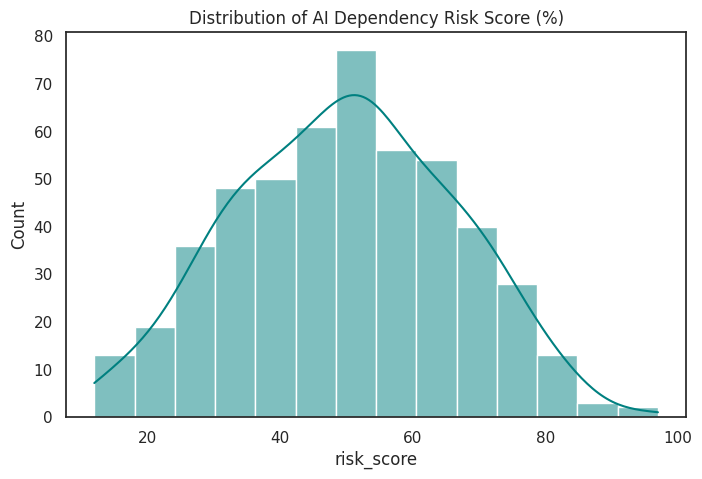

In [828]:
plt.figure(figsize=(8,5))
sns.histplot(df['risk_score'], kde=True, color='teal')
plt.title('Distribution of AI Dependency Risk Score (%)')
plt.show()

#### <font color='F08B51'>**4.4 Encoding Categorical Features**</font>

<font color='lightyellow'>We convert the 'role' and 'task_type' into numeric values so the model can process them.</font>

In [829]:
le = LabelEncoder()
X['role_n'] = le.fit_transform(df['role'])
X['task_n'] = le.fit_transform(df['task_type'])

#### <font color='F08B51'>**4.5 Train-Test Split**</font>

#### <font color='lightyellow'>We divide the dataset into training and testing sets.

- Training data → used to train the model
- Testing data → used to evaluate model performance
</font>

In [830]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### <font color='F08B51'>**4.6 Model Training**</font>

<font color='lightyellow'>We use Linear Regression as it is highly effective for predicting continuous scores based on linear behavioral patterns.</font>

In [831]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#### <font color='F08B51'>**4.8 Model Evaluation**</font>

In [832]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}%")
print(f"Model Accuracy (R2 Score): {r2:.4f}")

Mean Absolute Error (MAE): 5.28%
Model Accuracy (R2 Score): 0.8453
